In [1]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

from elfdannagalac.dmsrc import DMHalo,get_c_sub
from elfdannagalac.substructure import SubHaloPopulation


In [2]:
r200 = 3e3*u.kpc
m200 = 3.545e14*u.Msun


abel_cluster = DMHalo(
    "Abel",
    12*u.deg,
    27*u.deg,
    0.0308,
    m200,
    r200,
    dmsigmav=3.6e-24*u.cm**3/u.s,
    msub_min=3.5410271e9*u.Msun,
    msub_max=3.54e12*u.Msun,
    fsub=0.11,
    mpoints=5
)


2026-04-15 01:45:53.366 | WARNING  | elfdannagalac.dmsrc.halo:__init__:148 - Input R200 3000.000 kpc will be inconsistent with the rest of calculations.
 Setting R200 to the value obtained using the critical density: 1406.363 kpc
2026-04-15 01:46:22.599 | INFO     | elfdannagalac.dmsrc.halo:get_msub:651 - Computing mass in form of subhalos
2026-04-15 01:46:50.604 | INFO     | elfdannagalac.dmsrc.halo:get_average_subhalo_mass:713 - At this moment, the mass of the subhalo has not any dependance on the radial distance of the subhalo to the center of the host halo. Then, it is sufficient to just compute the average at the scale radius as the average subhalo mass is constant across the host halo.


In [3]:
abel_cluster.info

2026-04-15 01:46:53.420 | INFO     | elfdannagalac.dmsrc.halo:info:398 - 
Abel cluster configured with: 
	- Redshift: 0.031
	- D_lum: 129474.231 kpc
	- Coord: (12.000 deg,27.000 deg) [ICRS]
	- X: 112.841 Mpc
	- Y: 23.985 Mpc
	- Z: 58.780 Mpc
	- Cluster Radius [R200]: 1406.363 kpc
	- Total Mass [M200]: 3.545e+14 solMass
	- Scale radius: 86.108 kpc
	- Scale density: 2.313e+07 solMass / kpc3
	- Saturation Radius: 2.390e-07 kpc
	- Saturation Density: 8.333e+15 solMass / kpc3
	- Number of subhalos: 1116  (from [3.541e+09 solMass,3.540e+12 solMass])
	- Total mass in form of subhalos: 3.897e+13 solMass (11.0% of the cluster mass)
	- Average Subhalo Mass: 3.492e+10 solMass
	- Annihilation emissivity [No sub]: 1.431e+21 solMass2 / kpc3 (6.058e+70 GeV2 / cm3)
	- Annihilation emissivity [With sub]: 1.431e+21 solMass2 / kpc3 (6.058e+70 GeV2 / cm3)
	- Decay emissivity [No sub]: 3.545e+14 solMass (3.954e+71 GeV)
	- DM luminosity [Annihilation, No sub]: 3.49407e+42 erg / s
	- DM luminosity [Annihilat

In [4]:
abel_cluster.nsubs

1116

In [5]:
rvals = np.logspace(-2,np.log10(abel_cluster.r200.value),50)*abel_cluster.r200.unit

rhosub_vals = np.zeros_like(rvals.value)*u.Msun/abel_cluster.r200.unit**3

for i,r in enumerate(rvals):

    rhosub_vals[i] = abel_cluster.rho_sub(r)


Text(0, 0.5, '$\\rho_\\text{sub}$ [$M_\\odot$ kpc$^{-3}$]')

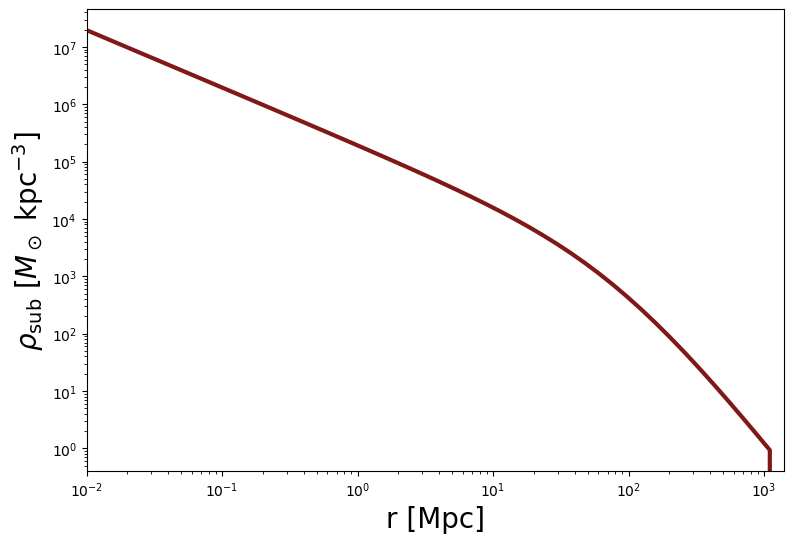

In [6]:
fig,ax = plt.subplots(figsize=(9,6))

ax.plot(rvals,rhosub_vals,lw=3,color="#801818")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(0.01,abel_cluster.r200.value)
ax.set_xlabel("r [Mpc]",fontsize=20)
ax.set_ylabel(r"$\rho_\text{sub}$ [$M_\odot$ kpc$^{-3}$]",fontsize=20)

In [7]:
rvals = np.logspace(-2,np.log10(abel_cluster.r200.value),50)*abel_cluster.r200.unit

rhosub_vals = np.zeros_like(rvals.value)*u.Msun/abel_cluster.r200.unit**3
rhotot_vals = np.zeros_like(rvals.value)*u.Msun/abel_cluster.r200.unit**3

for i,r in enumerate(rvals):

    rhosub_vals[i] = abel_cluster.rho_sub(r)
    rhotot_vals[i] = abel_cluster.rho_tot(r)

rho_smooth = rhotot_vals - rhosub_vals


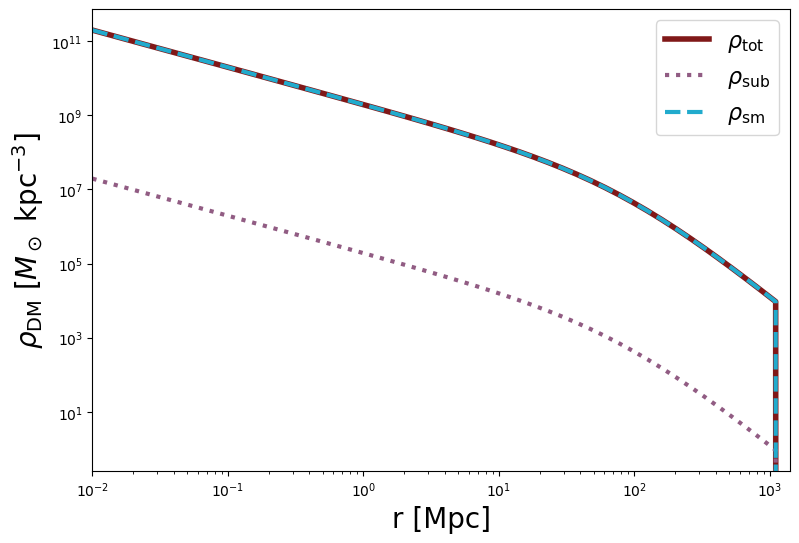

In [8]:
fig,ax = plt.subplots(figsize=(9,6))

ax.plot(rvals,rhotot_vals,lw=4,color="#801818",ls="-",label=r"$\rho_\text{tot}$")
ax.plot(rvals,rhosub_vals,lw=3,color="#915C83",ls=":",label=r"$\rho_\text{sub}$")
ax.plot(rvals,rho_smooth,lw=3,color="#21ABCD",ls="--",label=r"$\rho_\text{sm}$")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(0.01,abel_cluster.r200.value)
ax.set_xlabel("r [Mpc]",fontsize=20)
ax.set_ylabel(r"$\rho_\text{DM}$ [$M_\odot$ kpc$^{-3}$]",fontsize=20)

ax.legend(loc="best",fontsize=16)

# plt.savefig("DMDensity.png",dpi=300)

In [9]:
sh_pop = abel_cluster.shpop

In [10]:
sh_pop_table = sh_pop.to_qtable()
print(sh_pop_table.columns["msh"])

[5.63530107e+09 6.00990151e+09 7.09139506e+09 ... 4.29683059e+09
 4.46241012e+09 5.57896074e+09] solMass


In [11]:
x_ = sh_pop_table.columns["xsh"].to(u.Mpc)
y_ = sh_pop_table.columns["ysh"].to(u.Mpc)
z_ = sh_pop_table.columns["zsh"].to(u.Mpc)

In [12]:
bins = 101
H_xy,x_edges,y_edges = np.histogram2d(x_,y_,bins=bins)
H_xz,_,z_edges       = np.histogram2d(x_,z_,bins=bins)
H_yz,_,_             = np.histogram2d(y_,z_,bins=bins)

X,Y            = np.meshgrid(x_edges[:-1],y_edges[:-1])
X_flat,Z_flat  = np.meshgrid(x_edges[:-1],z_edges[:-1])
Y_flat,Z_flat2 = np.meshgrid(y_edges[:-1],z_edges[:-1])


[(111.4875422918431, 114.18476066487061),
 (22.619588850921147, 25.263326821521613),
 (57.480478058420466, 60.044099702854204)]

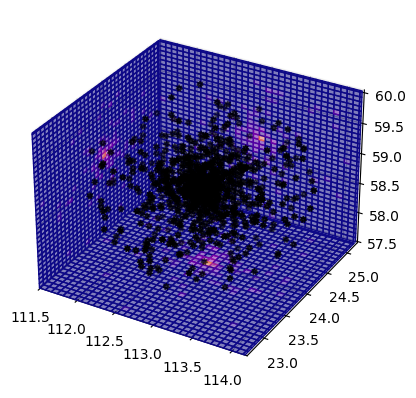

In [13]:
ax = plt.figure().add_subplot(projection='3d')

ax.scatter(x_,y_,z_,marker=(7,1,0),color="black")


ax.plot_surface(
    np.full_like(Y_flat,x_.min()),
    Y_flat,
    Z_flat2,
    facecolors=plt.cm.plasma(H_yz.T/H_yz.max()),
    alpha=0.5,
    shade=False
)


ax.plot_surface(
    X_flat,
    np.full_like(X_flat,y_.max()),
    Z_flat,
    facecolors=plt.cm.plasma(H_xz.T/H_xz.max()),
    alpha=0.5,
    shade=False
)

ax.plot_surface(
    X,
    Y,
    np.full_like(X,z_.min()),
    facecolors=plt.cm.plasma(H_xy.T/H_xy.max()),
    alpha=0.5,
    shade=False
)


ax.set(
    xlim=(x_.min().value,x_.max().value,),
    ylim=(y_.min().value,y_.max().value,),
    zlim=(z_.min().value,z_.max().value,),
)


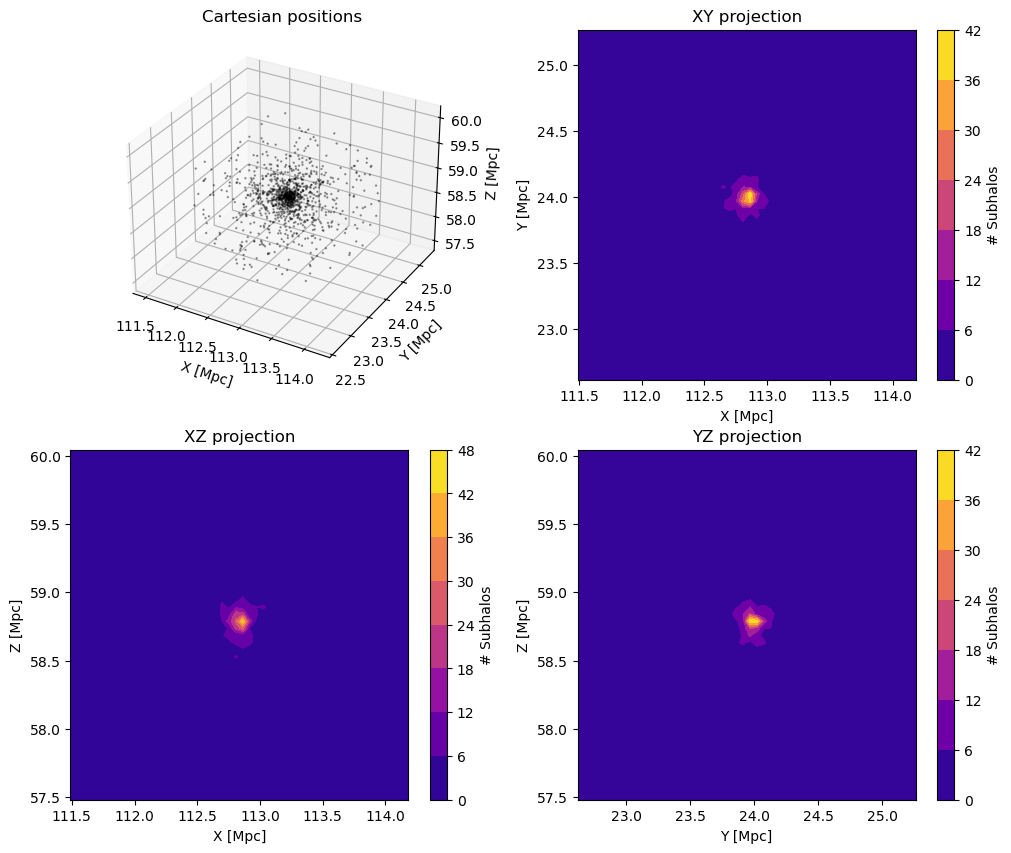

In [14]:
fig = plt.figure(figsize=(12,10))

ax1 = fig.add_subplot(2,2,1,projection='3d')
ax1.scatter(
    x_,
    y_,
    z_,
    marker=(7,1,0),
    s=5,
    alpha=0.5,
    color="black",
    edgecolors="none"
)

ax1.set_xlabel("X [Mpc]")
ax1.set_ylabel("Y [Mpc]")
ax1.set_zlabel("Z [Mpc]")
ax1.set_title("Cartesian positions")


ax2 = fig.add_subplot(2,2,2)

h2 = ax2.contourf(
    np.histogram2d(
        x_.value,
        y_.value,
        bins=50
    )[0].T,
    extent=[
        x_.value.min(),
        x_.value.max(),
        y_.value.min(),
        y_.value.max(),

    ],
    cmap="plasma"
)

ax2.set_xlabel("X [Mpc]")
ax2.set_ylabel("Y [Mpc]")
ax2.set_title("XY projection")
plt.colorbar(h2,ax=ax2,label="# Subhalos")


ax3 = fig.add_subplot(2,2,3)

h3 = ax3.contourf(
    np.histogram2d(
        x_.value,
        z_.value,
        bins=50
    )[0].T,
    extent=[
        x_.value.min(),
        x_.value.max(),
        z_.value.min(),
        z_.value.max(),

    ],
    cmap="plasma"
)

ax3.set_xlabel("X [Mpc]")
ax3.set_ylabel("Z [Mpc]")
ax3.set_title("XZ projection")
plt.colorbar(h3,ax=ax3,label="# Subhalos")


ax4 = fig.add_subplot(2,2,4)

h4 = ax4.contourf(
    np.histogram2d(
        y_.value,
        z_.value,
        bins=50
    )[0].T,
    extent=[
        y_.value.min(),
        y_.value.max(),
        z_.value.min(),
        z_.value.max(),

    ],
    cmap="plasma"
)

ax4.set_xlabel("Y [Mpc]")
ax4.set_ylabel("Z [Mpc]")
ax4.set_title("YZ projection")
plt.colorbar(h4,ax=ax4,label="# Subhalos")


# plt.savefig("AbelToy_subhalos.png",dpi=300)

In [15]:
masses = sh_pop_table.columns["msh"]
c_subh = sh_pop_table.columns["csh"]

Text(0, 0.5, 'c$_\\text{sub}$/c$_\\text{mean}$')

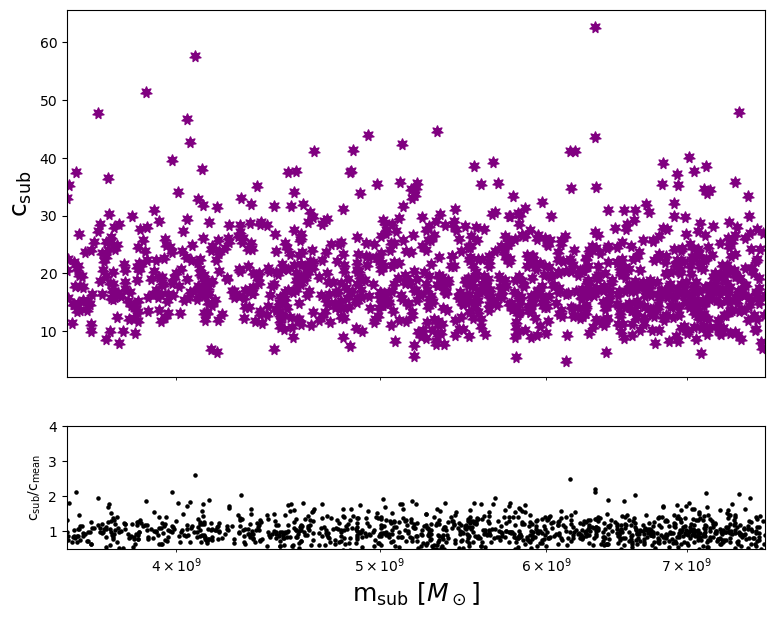

In [16]:
_,(ax1,ax2) = plt.subplots(figsize=(9,7),nrows=2, ncols=1,gridspec_kw={'height_ratios': [3, 1]},sharex=True)

cmean  = get_c_sub(
    masses,
    sh_pop_table.columns["rsh"],
    abel_cluster.r200,
    abel_cluster.h,
    clabel=abel_cluster.cM_sub
)

ax1.scatter(masses,c_subh,marker=(7,1,0),color="purple",s=65)
ax2.scatter(masses,c_subh/cmean,marker="o",color="black",s=5)

ax1.set_xscale("log")
ax1.set_ylabel(r"c$_\text{sub}$",fontsize=18)

ax1.set_xlim(masses.value.min(),masses.value.max())
ax2.set_ylim(0.5,4)

ax2.set_xlabel(r"m$_\text{sub}$ [$M_\odot$]",fontsize=18)
ax2.set_ylabel(r"c$_\text{sub}$/c$_\text{mean}$")

# plt.savefig("SH_Concentration.png",dpi=200)

In [17]:

sh_pop_table

msh,rsh,xsh,ysh,zsh,csh,r200,rhos,rs,lanna,cross
solMass,kpc,kpc,kpc,kpc,,kpc,solMass / kpc3,kpc,solMass2 / kpc3,solMass2 / kpc3
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
5635301073.593086,1384.526518833803,112683.63583015226,22619.588850921147,58615.29983374426,21.930421983661883,35.361535460129645,49156514.83814365,1.6124420901008614,4.2436462884157416e+16,55577899034837.664
6009901505.474359,1269.357160483418,112664.50894093286,22926.132679742605,58103.044900485496,11.719605767468835,36.12832758870433,10066197.382409032,3.082725503360274,1.244042306900362e+16,76103144993568.86
7091395056.04602,1111.565090107545,112088.54705171182,23286.18267172107,59204.47712724687,21.87351139510935,38.17707344132381,48828140.4783487,1.7453564154249024,5.310282816752366e+16,131345751199805.53
7325503825.274881,1030.7319087789358,112142.70395598837,24483.210774309206,59351.16668087278,16.628931752211656,38.59264754029425,24209768.339715224,2.320813394111225,3.0695154261741276e+16,168269643927860.9
4832447883.401177,176.56571130015277,112837.45397875868,24075.200701548845,58628.22433250461,14.119282512873578,33.59550185108721,16018317.51642367,2.379405739665294,1.4482835448706834e+16,1.1714511337912962e+16
5212110138.160897,369.11001143383993,112886.74508412242,24308.89931915659,58951.53762006386,9.838902227506642,34.45322931584591,6547017.274777445,3.501735104097786,7715545643572357.0,2012403491429431.5
5273460658.0204115,91.99066090056357,112847.7209383001,24040.656771056274,58853.187762255904,25.82798620768259,34.587882645889366,75100254.62551317,1.339162967169354,5.674063780851464e+16,5.337374913252688e+16
4480487554.6342325,481.03524079557644,112860.40677287175,24418.22389969743,58988.67431254871,12.901347234771691,32.759241056291444,12781140.061654544,2.5392108638079898,1.120690767641784e+16,855182740153439.2


In [18]:
sh_pop.to_qtable()

msh,rsh,xsh,ysh,zsh,csh,r200,rhos,rs,lanna,cross
solMass,kpc,kpc,kpc,kpc,,kpc,solMass / kpc3,kpc,solMass2 / kpc3,solMass2 / kpc3
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
5635301073.593086,1384.526518833803,112683.63583015226,22619.588850921147,58615.29983374426,21.930421983661883,35.361535460129645,49156514.83814365,1.6124420901008614,4.2436462884157416e+16,55577899034837.664
6009901505.474359,1269.357160483418,112664.50894093286,22926.132679742605,58103.044900485496,11.719605767468835,36.12832758870433,10066197.382409032,3.082725503360274,1.244042306900362e+16,76103144993568.86
7091395056.04602,1111.565090107545,112088.54705171182,23286.18267172107,59204.47712724687,21.87351139510935,38.17707344132381,48828140.4783487,1.7453564154249024,5.310282816752366e+16,131345751199805.53
7325503825.274881,1030.7319087789358,112142.70395598837,24483.210774309206,59351.16668087278,16.628931752211656,38.59264754029425,24209768.339715224,2.320813394111225,3.0695154261741276e+16,168269643927860.9
4832447883.401177,176.56571130015277,112837.45397875868,24075.200701548845,58628.22433250461,14.119282512873578,33.59550185108721,16018317.51642367,2.379405739665294,1.4482835448706834e+16,1.1714511337912962e+16
5212110138.160897,369.11001143383993,112886.74508412242,24308.89931915659,58951.53762006386,9.838902227506642,34.45322931584591,6547017.274777445,3.501735104097786,7715545643572357.0,2012403491429431.5
5273460658.0204115,91.99066090056357,112847.7209383001,24040.656771056274,58853.187762255904,25.82798620768259,34.587882645889366,75100254.62551317,1.339162967169354,5.674063780851464e+16,5.337374913252688e+16
4480487554.6342325,481.03524079557644,112860.40677287175,24418.22389969743,58988.67431254871,12.901347234771691,32.759241056291444,12781140.061654544,2.5392108638079898,1.120690767641784e+16,855182740153439.2


In [19]:
small = SubHaloPopulation.from_qtable(sh_pop.to_qtable()[:100])

In [20]:
sh_pop[0:10]

<SubhaloContainer: 10 subhalos, mass unit=solMass,length unit=kpc>

In [21]:
sh_pop[:100].save_to_fits("AbelSubHaloSample.fits.gz")

In [22]:
lanna_sh = np.sum(sh_pop_table["lanna"])
lcross   = np.sum(sh_pop_table["cross"])
lsmooth  = abel_cluster.l_dm_anna_sub-(lanna_sh+lcross)
boost    = abel_cluster.l_dm_anna_sub/lsmooth

In [23]:
print("Luminosity from all the different contributions:")
print(f"Subhalos: {lanna_sh:0.5e}")
print(f"Cross: {lcross:0.5e}")
print(f"Smooth: {lsmooth:0.5e}")
print(f"Boost factor: {boost}")

Luminosity from all the different contributions:
Subhalos: 4.26565e+19 solMass2 / kpc3
Cross: 4.42191e+19 solMass2 / kpc3
Smooth: 1.34365e+21 solMass2 / kpc3
Boost factor: 1.064656357353802
